In [57]:
import json

def load_json(filename):
    with open(filename) as file:
        return json.load(file)

In [58]:
import pandas as pd

filename = "6,7,8"
output_path = f"{filename}.pdf"
report_path = f"../../outputs/reports/2025/{filename}.json"
text_segmentation_path = f"../../outputs/text_segmentation/2025/{filename}.json"

report_df = pd.read_json(report_path)
report = load_json(report_path)
text_segmentation = load_json(text_segmentation_path)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import calendar

def reviews_date_plot(df: pd.DataFrame, method_name: str, pdf: PdfPages):
    reviews_per_day = df.groupby(df['timestamp'].dt.date).size()
    
    fig, ax = plt.subplots()
    reviews_per_day.plot(kind='bar', ax=ax)

    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_title(f"{method_name} Method")
    ax.set_xlabel("Date")
    ax.set_ylabel("Review Count")
    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()
    
    # pdf.savefig(fig)
    # plt.close(fig)

def reviews_month_pie_chart(df: pd.DataFrame, method_name: str, pdf: PdfPages):
    reviews_per_month = df.groupby(df['timestamp'].dt.month).size()
    
    reviews_per_month.index = reviews_per_month.index.map(lambda x: calendar.month_name[x])
    
    fig, ax = plt.subplots()
    
    ax.pie(
        reviews_per_month.values,
        labels=reviews_per_month.index,  
        autopct='%1.1f%%',              
        startangle=90,
        textprops={'fontsize': 14}
    )
    
    ax.set_title(f"{method_name} Method")
    ax.axis('equal')  

    plt.show()

    # pdf.savefig(fig)
    # plt.close(fig)

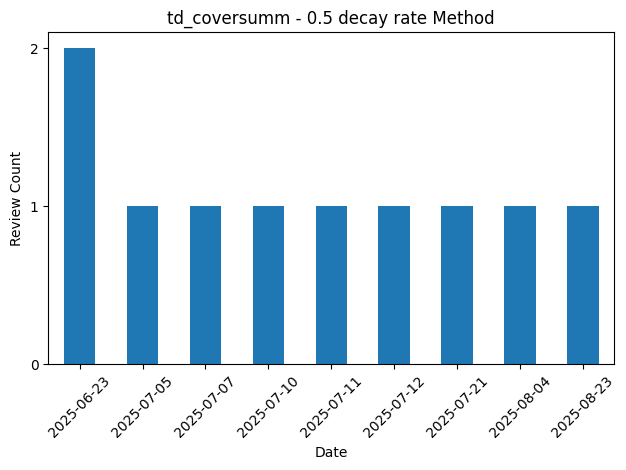

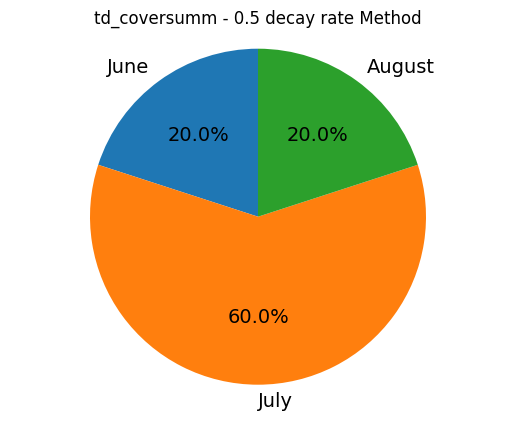

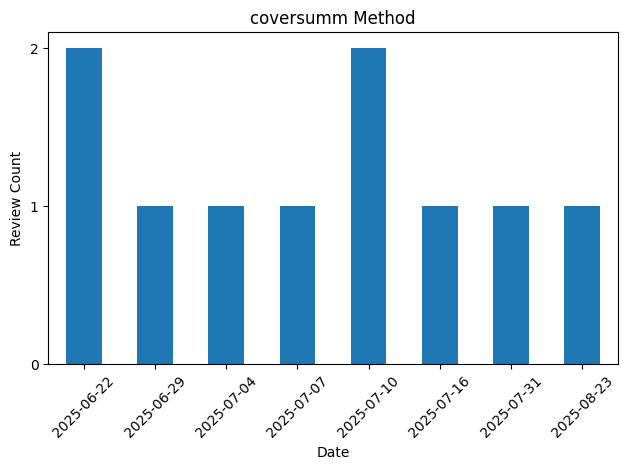

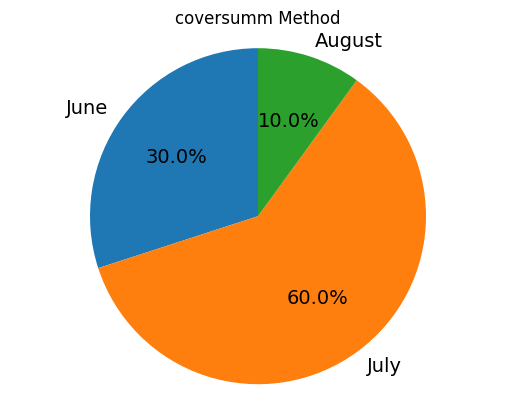

In [60]:
with PdfPages(output_path) as pdf:
    for report_val in report.values():
        reviews = []
        for idx in report_val['summary_id']:
            selected_review = text_segmentation.get(f'{idx}')
            reviews.append({
                'id': idx,
                'text': selected_review['text'],
                'timestamp': selected_review['timestamp'],
            })

        reviews_df = pd.DataFrame(reviews)
        reviews_df['timestamp'] = pd.to_datetime(reviews_df['timestamp'])

        reviews_date_plot(reviews_df, report_val['summarizer'], pdf)
        reviews_month_pie_chart(reviews_df, report_val['summarizer'], pdf)